In [492]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate
from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
import matplotlib.pyplot as plt
import matplotlib.ticker as tck  # Import the ticker module
import seaborn as sns



In [493]:

top20_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

In [494]:
# Ticker

symbols = ["LTC"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 18)
start = pd.to_datetime("2025-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3  #atr multiplier for chandelier exit
adx_threshold = 25  #trend strength
ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
# init_cash = 1000

#
k = KrakenHistoricalData()
s = Signals()
# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)

print(df_multi.head())

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.head())

                                 LTC                                   \
                                open       high        low      close   
2023-01-01 00:00:00+00:00  70.019997  70.089996  69.199997  69.339996   
2023-01-01 04:00:00+00:00  69.300003  69.779999  69.199997  69.269997   
2023-01-01 08:00:00+00:00  69.250000  70.160004  68.959999  70.010002   
2023-01-01 12:00:00+00:00  69.989998  70.559998  69.760002  69.949997   
2023-01-01 16:00:00+00:00  69.900002  70.800003  69.599998  70.750000   

                                                           
                                 volume trades base quote  
2023-01-01 00:00:00+00:00  6.056087e+07    497  LTC   USD  
2023-01-01 04:00:00+00:00  3.314963e+07    410  LTC   USD  
2023-01-01 08:00:00+00:00  1.663437e+07    306  LTC   USD  
2023-01-01 12:00:00+00:00  1.709356e+07    279  LTC   USD  
2023-01-01 16:00:00+00:00  2.829356e+07    428  LTC   USD  

MultiIndex Removed
                                 open        hig

In [495]:
# Signals
signals = df.copy()
# moving average
# ma = pta.ohlc4(df['open'],df['high'],df['low'],df['close'])
ma = pta.zlma(df['close'], 10)

# Calculate technical indicators
signals['rsi'] = pta.rsi(df['close'])

# adx > 25 strong trend
adx = pta.adx(df['high'], df['low'], df['close'])

# Entry: SAR Signal
psar = pta.psar(df['high'],
                df['low'],
                close=df['close'])
print(f"\nSAR:")

signals['sar'] = psar.iloc[:, 0]
# signals['sar_s'] = np.where(signals['sar'] > 0, True, False)

signals['sar_s'] = signals['close'] > signals['sar']

print(signals[['sar', 'sar_s']].tail())  # Entry Signals

print(f"\nADX:")
print(tabulate(adx.tail(), headers="keys", tablefmt="github"))
signals['adx'] = adx.iloc[:, 0]
signals['adx_d'] = adx.iloc[:, 1]
signals['adx_dmp'] = adx.iloc[:, 2]
signals['adx_dmn'] = adx.iloc[:, 3]
signals['adx_s'] = np.where(signals['adx'] > adx_threshold, True, False)
signals['adx_bullish'] = np.where(signals['adx_dmp'] > signals['adx_dmn'], True, False)
signals['adx_s'] = signals['adx_s'] & signals['adx_bullish']

# Exit: Chandlier Exit uses ATR
signals['atr'] = pta.atr(df['high'], df['low'], df['close'])
ce = pta.chandelier_exit(df['high'],
                         df['low'],
                         df['close'],
                         multiplier=atr_multiplier, high_length=ce_high_length)
print(f"\nChandelier_Raw")
print(tabulate(ce.tail(), headers="keys", tablefmt="github"))
signals['ce_l'] = np.where(ce.iloc[:, 2] > 0, ce.iloc[:, 0], np.nan)
signals['ce_sh'] = np.where(ce.iloc[:, 2] < 0, ce.iloc[:, 1], np.nan)
signals['ce_exit'] = np.where(ce.iloc[:, 2] == 1, False, True)
print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].tail(50))

# entry

# Have ADX strength, and sar is a buy and ce is not an exit
entry_series = signals['adx_s'] & signals['sar_s'] & ~signals['ce_exit']
entry_rise = entry_series & (~entry_series.shift(1, fill_value=False))

# exitt
exit_series = signals['ce_exit']

exit_rise = exit_series & (~exit_series.shift(1, fill_value=False))

entry_exit_df = pd.concat([entry_series, entry_rise, exit_series, exit_rise], axis=1)
entry_exit_df.columns = ['entry_series', 'entry_rise', 'exit_series', 'exit_rise']

print(f"\nEntry/Exit Signals:")
print(entry_exit_df.tail(50))



SAR:
                                  sar  sar_s
2025-09-29 08:00:00+00:00  103.823492   True
2025-09-29 12:00:00+00:00  104.226273   True
2025-09-29 16:00:00+00:00  104.697194   True
2025-09-29 20:00:00+00:00  105.102187   True
2025-09-30 00:00:00+00:00  105.450480   True

ADX:
|                           |   ADX_14 |   ADXR_14_2 |   DMP_14 |   DMN_14 |
|---------------------------|----------|-------------|----------|----------|
| 2025-09-29 08:00:00+00:00 |  29.3625 |     31.4022 |  3.71335 |  4.05264 |
| 2025-09-29 12:00:00+00:00 |  27.9938 |     29.6394 |  4.61811 |  3.76316 |
| 2025-09-29 16:00:00+00:00 |  26.7229 |     28.0427 |  4.28825 |  3.49437 |
| 2025-09-29 20:00:00+00:00 |  25.9108 |     26.9523 |  4.42195 |  3.24477 |
| 2025-09-30 00:00:00+00:00 |  25.2073 |     25.9651 |  4.16609 |  3.013   |

Chandelier_Raw
|                           |   CHDLREXTl_22_22_14_3 |   CHDLREXTs_22_22_14_3 |   CHDLREXTd_22_22_14_3 |
|---------------------------|------------------------|----

In [496]:
# filter entries and exits, one for one entry/exit
def filter_entries_exits(entry_rise: pd.Series, exit_rise: pd.Series):
    in_pos = False
    filtered_entry = pd.Series(False, index=signals.index)
    filtered_exit = pd.Series(False, index=signals.index)
    in_position = pd.Series(False, index=signals.index)

    for ts in signals.index:
        if not in_pos and entry_rise.loc[ts]:
            filtered_entry.loc[ts] = True
            in_pos = True
        elif in_pos and exit_rise.loc[ts]:
            filtered_exit.loc[ts] = True
            in_pos = False
        in_position.loc[ts] = in_pos

    return pd.DataFrame({
        'filtered_entry': filtered_entry,
        'filtered_exit': filtered_exit,
        'in_position': in_position
    })


filtered_entry_exit = filter_entries_exits(entry_rise, exit_rise)
print(filtered_entry_exit.head(65))
filtered_entry = filtered_entry_exit['filtered_entry']
filtered_exit = filtered_entry_exit['filtered_exit']
in_position = filtered_entry_exit['in_position']


                           filtered_entry  filtered_exit  in_position
2025-01-01 00:00:00+00:00           False          False        False
2025-01-01 04:00:00+00:00           False          False        False
2025-01-01 08:00:00+00:00           False          False        False
2025-01-01 12:00:00+00:00           False          False        False
2025-01-01 16:00:00+00:00           False          False        False
...                                   ...            ...          ...
2025-01-11 00:00:00+00:00           False          False        False
2025-01-11 04:00:00+00:00           False          False        False
2025-01-11 08:00:00+00:00           False          False        False
2025-01-11 12:00:00+00:00           False          False        False
2025-01-11 16:00:00+00:00           False          False        False

[65 rows x 3 columns]


                           Entry_Price  Exit_Price       close   Returns  Window_Profit       Equity
2025-09-28 12:00:00+00:00     0.000000         0.0  104.599998  0.000000            NaN  1305.818173
2025-09-28 16:00:00+00:00     0.000000         0.0  105.629997  0.000000            NaN  1305.818173
2025-09-28 20:00:00+00:00   106.860001         0.0  106.860001  0.008394            NaN  1316.779800
2025-09-29 00:00:00+00:00     0.000000         0.0  106.550003 -0.002901            NaN  1312.959863
2025-09-29 04:00:00+00:00     0.000000         0.0  106.029999 -0.004880            NaN  1306.552123
2025-09-29 08:00:00+00:00     0.000000         0.0  105.750000 -0.002641            NaN  1303.101844
2025-09-29 12:00:00+00:00     0.000000         0.0  106.349998  0.005674            NaN  1310.495311
2025-09-29 16:00:00+00:00     0.000000         0.0  106.430000  0.000752            NaN  1311.481132
2025-09-29 20:00:00+00:00     0.000000         0.0  106.800003  0.003476            NaN  13

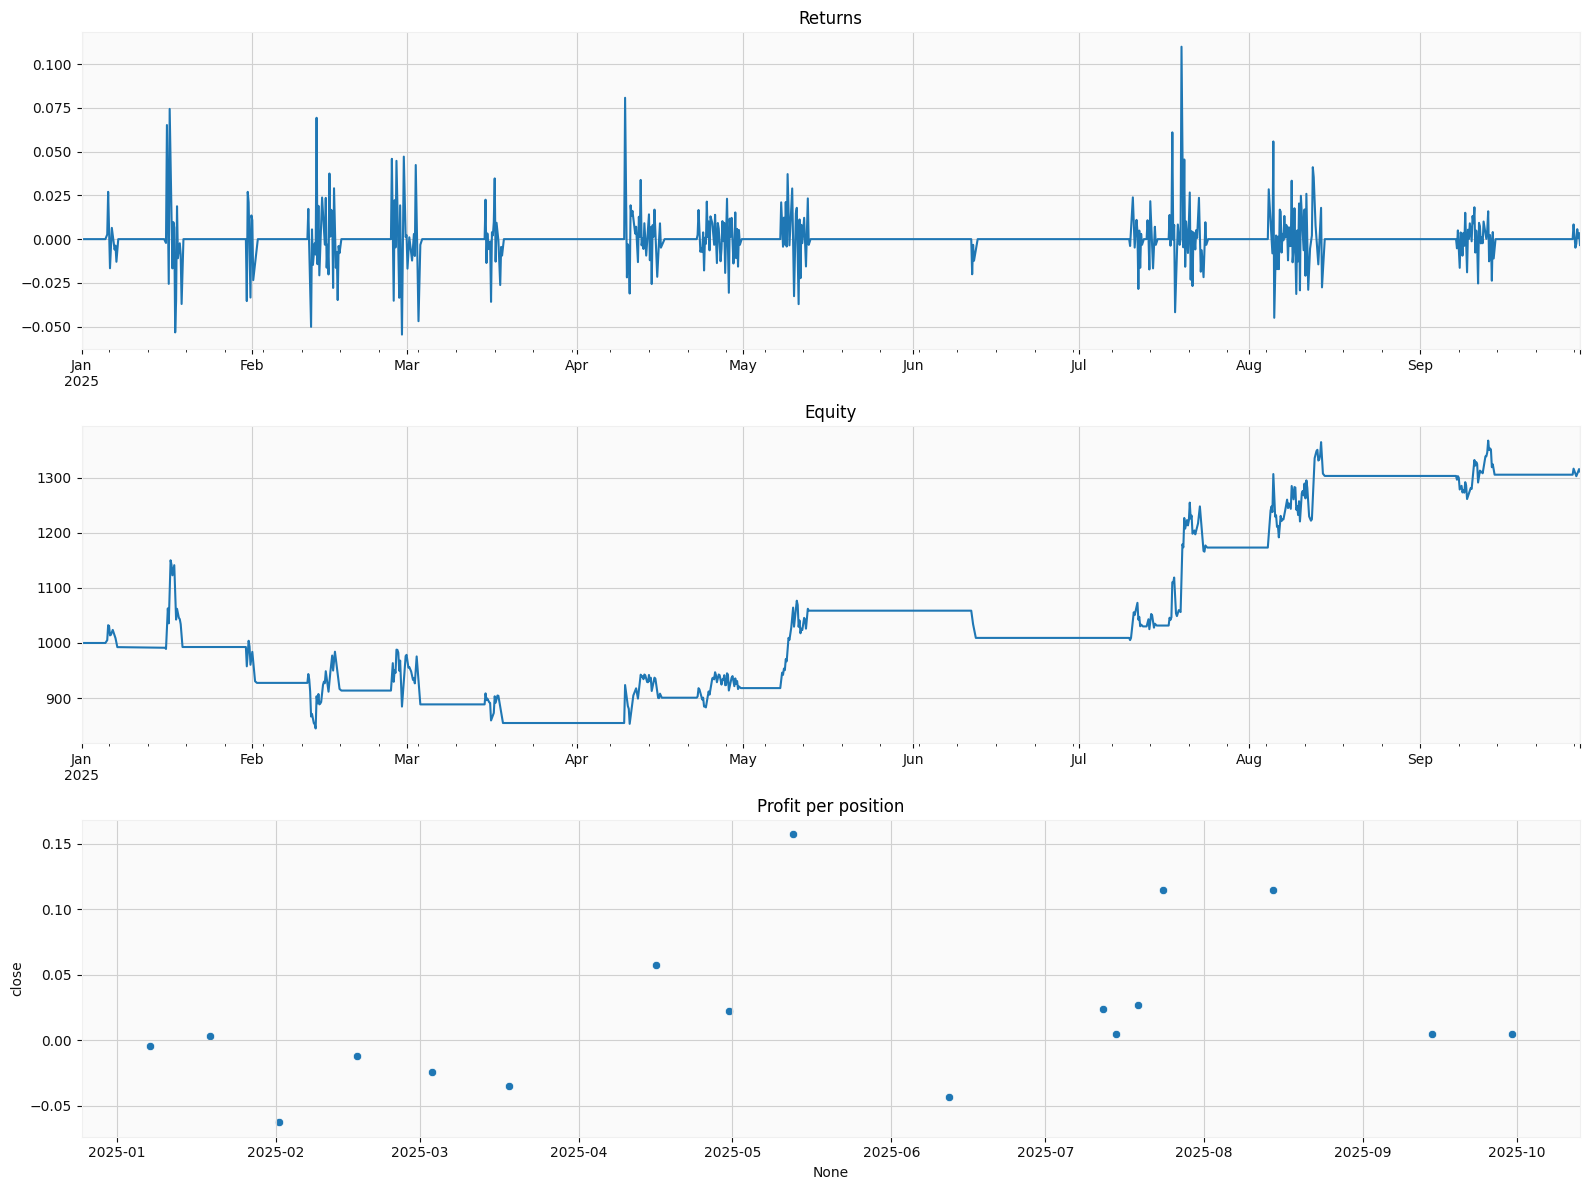

In [497]:
def position_time_pairs(entry_times: pd.Series, exit_times: pd.Series):
    # 2) Pair entries with the next exit after each entry
    pairs = []
    j = 0
    for et in entry_times:
        while j < len(exit_times) and exit_times[j] <= et:
            j += 1
        if j < len(exit_times):
            pairs.append((et, exit_times[j]))
            j += 1
    return pairs


def calc_wins_losses(profit: pd.Series):
    wins = (profit > 0).sum()
    loss = (profit < 0).sum()
    win_rate = wins / (wins + loss)
    return wins, loss, win_rate


def profit_per_position(returns: pd.DataFrame, in_position: pd.Series) -> pd.Series:
    # Ensure aligned indices
    returns = returns.reindex(in_position.index).astype(float)
    in_pos = in_position.fillna(False).astype(bool)

    # Create group ids for contiguous True runs; 0 for out of position
    # Each time in_pos flips from previous value, we increment a counter
    flips = in_pos.ne(in_pos.shift(fill_value=False)).cumsum()
    grp = flips.where(in_pos, 0)

    # Filter to only groups > 0 (actual positions)
    mask = grp > 0
    if not mask.any():
        return pd.Series(dtype=float)

    # Compute compounded return per position
    # Drop NaNs in returns for stability
    r = returns.fillna(0.0)
    window_ret = ((1.0 + r[mask]).groupby(grp[mask]).prod() - 1.0)

    if window_ret.empty:
        return window_ret

    # Map each group id to its exit timestamp: last index where that grp appears
    # If the last bar is still in an open position, exclude that group since there's no exit yet
    last_index_per_grp = grp[mask].groupby(grp[mask]).apply(lambda s: s.index[-1])

    # Keep only groups present in window_ret (they should match)
    last_index_per_grp = last_index_per_grp.reindex(window_ret.index)

    # Assign exit timestamps as the index
    window_ret.index = pd.Index(last_index_per_grp.values, name=returns.index.name)
    window_ret.index = pd.DatetimeIndex(window_ret.index).tz_localize('UTC')
    return pd.DataFrame(window_ret)


def calc_returns(close: pd.DataFrame, filtered_entry_exit: pd.DataFrame, exits_price: pd.Series, transaction_fee: float = 0.004):
    #returns
    price = close.copy().astype("float64")
    price[filtered_entry_exit['filtered_exit']] = exits_price[filtered_entry_exit['filtered_exit']]

    in_position = filtered_entry_exit['in_position'].astype(bool)
    r_cc = price.pct_change().fillna(0.0)  # close-to-close returns
    enter_bar = filtered_entry_exit['filtered_entry'].astype(bool)
    exit_bar = filtered_entry_exit['filtered_exit'].astype(bool)

    returns = r_cc.where(in_position, 0.0)
    returns = returns.mask(enter_bar, returns - transaction_fee)  # apply fee at entry
    returns = returns.mask(exit_bar, returns - transaction_fee)  # apply fee at exit
    return returns


# Backtest

# Calc profits
close = signals['close']
exits_price = signals['ce_l'].shift(-1).ffill() * filtered_exit
entries_price = close * filtered_entry
returns = calc_returns(close, filtered_entry_exit, exits_price, transaction_fee=transaction_fee)
start_equity = 1000.0
equity = start_equity * (1.0 + returns).cumprod()
window_ret = profit_per_position(returns, in_position)

profit_df = pd.concat([entries_price, exits_price, close, returns, window_ret, equity], axis=1)
profit_df.columns = ['Entry_Price', 'Exit_Price','close', 'Returns', 'Window_Profit', 'Equity']
print(profit_df.tail(10).to_string())

# plots
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
returns.plot(ax=axes[0], title='Returns')
equity.plot(ax=axes[1], title='Equity')
sns.scatterplot(x=window_ret.index, y='close', data=window_ret, ax=axes[2])
axes[2].set_title('Profit per position')
plt.tight_layout()
plt.show()


In [498]:

def sharpe_ratio(returns: pd.Series, interval: str):
    trading_map = {'4h': 6 * 365, '1h': 24 * 365, '1d': 365}
    trading_periods = trading_map.get(interval)
    return returns.mean() / returns.std() * np.sqrt(trading_periods)


def sortino_ratio(returns: pd.Series, interval: str):
    trading_map = {'4h': 6 * 365, '1h': 24 * 365, '1d': 365}
    trading_periods = trading_map.get(interval)
    return returns.mean() / returns[returns < 0].std() * np.sqrt(trading_periods)


sharpe = sharpe_ratio(returns, interval)
sortino = sortino_ratio(returns, interval)
wins, loss, win_rate = calc_wins_losses(profit_df['Window_Profit'])

stats = {'trading_days': (end - start).days}
stats['total_profit'] = equity.iloc[-1] - equity.iloc[0]
stats['total_profit_pct'] = stats['total_profit'] / equity.iloc[0] * 100
stats['sharpe'] = sharpe
stats['sortino'] = sortino
stats['wins'] = wins
stats['losses'] = loss
stats['win_rate'] = win_rate

print(f"\nPerformance  Stats:")
print(tabulate(stats.items(), tablefmt="github"))


Performance  Stats:
|------------------|------------|
| trading_days     | 272        |
| total_profit     | 311.604    |
| total_profit_pct |  31.1604   |
| sharpe           |   1.03628  |
| sortino          |   0.871736 |
| wins             |  11        |
| losses           |   6        |
| win_rate         |   0.647059 |


In [499]:
##  Boolean where in position
y1_arr = signals['close'].values

y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]

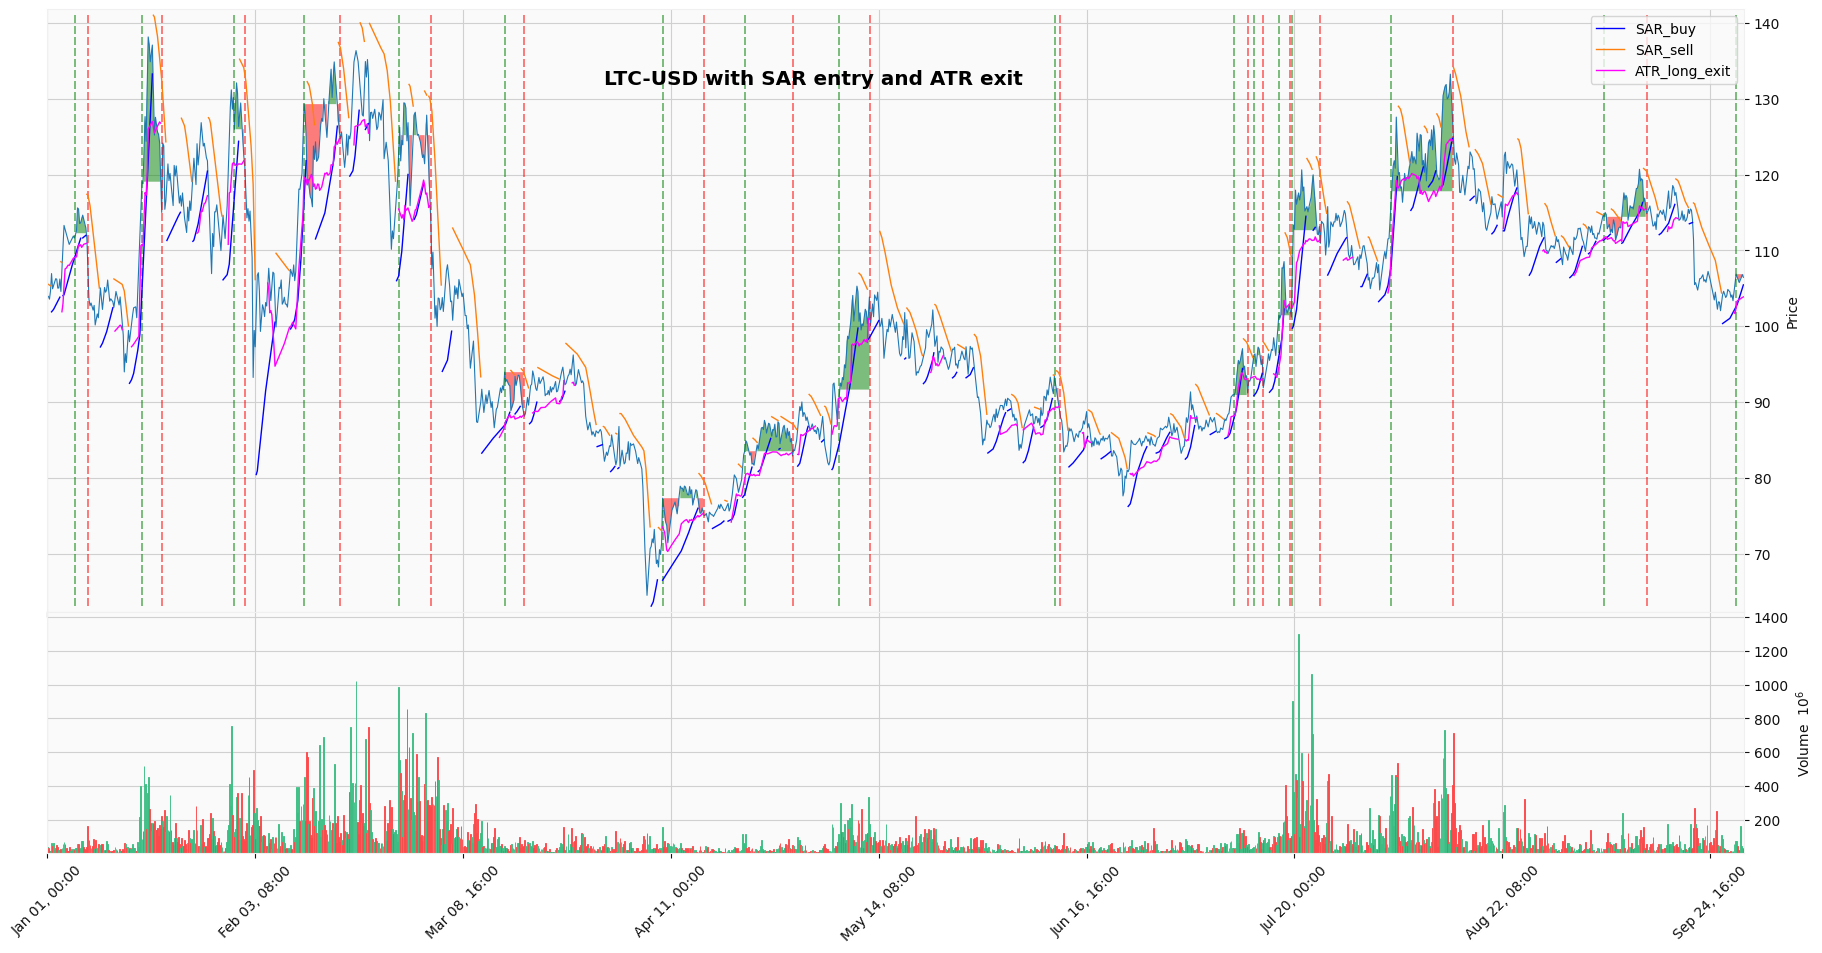

In [500]:
# Combine and color differently
# Build sorted timestamps with colors (keeps colors aligned with dates)
entries = [(ts, 'g') for ts in filtered_entry[filtered_entry].index]
exits   = [(ts, 'r') for ts in filtered_exit[filtered_exit].index]
pairs = sorted(entries + exits, key=lambda x: x[0])

# Extract in order expected by mplfinance
vline_dates  = [ts for ts, _ in pairs]
vline_colors = [c  for _,  c in pairs]

adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(psar.iloc[:, 0], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(psar.iloc[:, 1], type='line', width=1.0, label='SAR_sell'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),
    # mpf.make_addplot(signals['ce_sh'], type='line', width=1.0, label='ATR_short_exit',
    #                  secondary_y=False),
    # mpf.make_addplot(signals['adx'], type='line', color='blue', width=1.0, label='ADX', panel=1),
    # mpf.make_addplot(signals['adx_dmp'], type='line', linestyle='--', width=1.0, label='dmp', panel=1),
    # mpf.make_addplot(signals['adx_dmn'], type='line', linestyle='--', width=1.0, label='dmn', panel=1),
    # mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),
    # mpf.make_addplot(profit_cum, type='line', width=1.0, label='Profit', panel=2),
    # mpf.make_addplot(zero_line, type='line', color="black", linestyle='--', width=1.0, label='Zero_line', panel=2,
    #                  secondary_y=False),
    # mpf.make_addplot(profit, type='scatter', panel=3),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title=f"{symbols[0]}-USD with SAR entry and ATR exit",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)


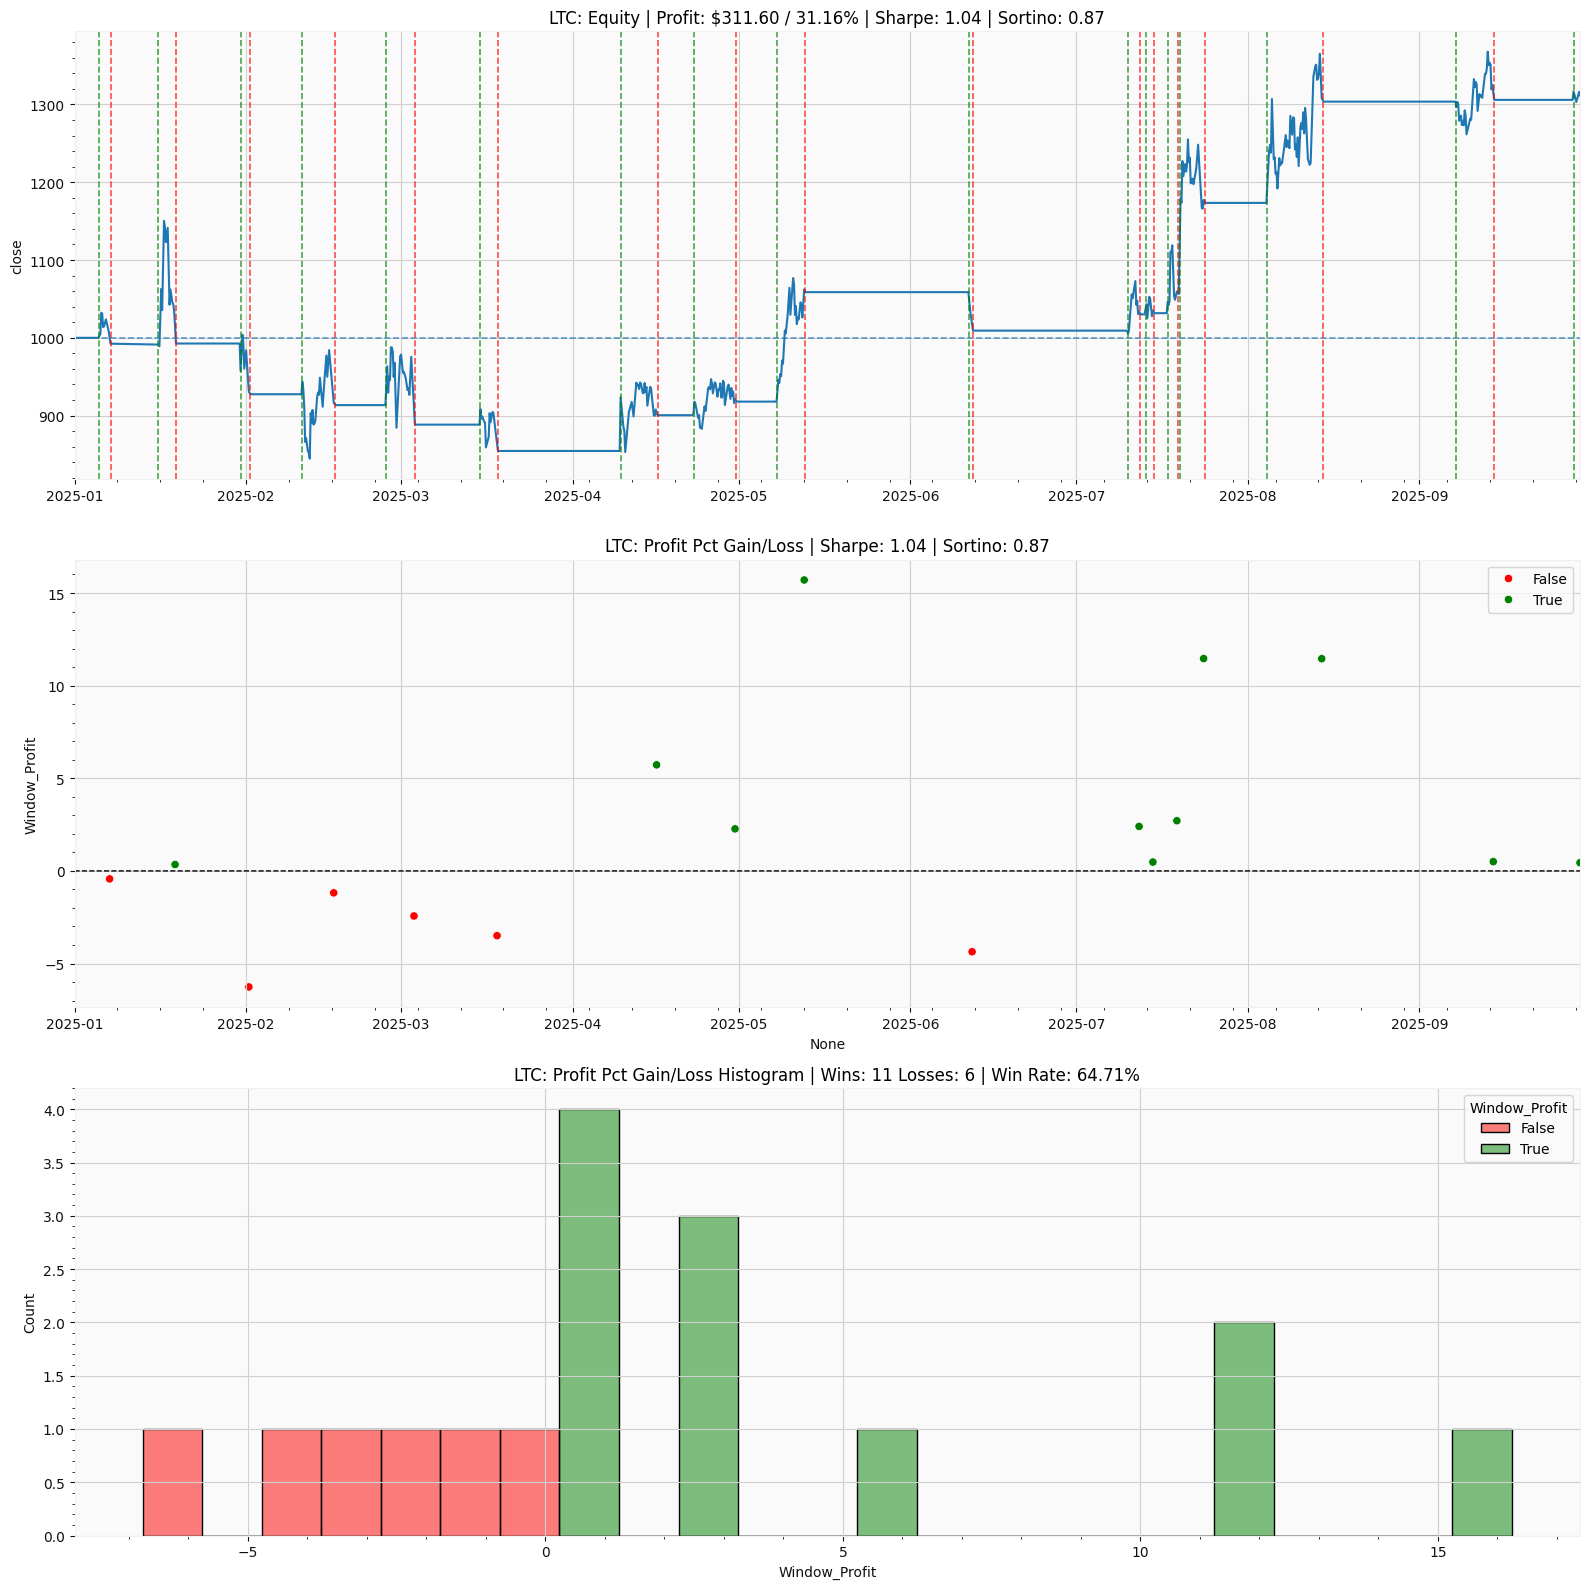

In [501]:
fig, axes = plt.subplots(3, 1, figsize=(16, 16))  # wider figure

# Equity
sns.lineplot(data=equity, ax=axes[0])
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
for ts, c in pairs:
    axes[0].axvline(ts, color=c, linestyle='--', linewidth=1.2, alpha=0.7)

axes[0].set_title(
    f"{symbols[0]}: Equity | Profit: ${stats['total_profit']:.2f} / {stats['total_profit_pct']:.2f}% | Sharpe: {sharpe:.2f} | Sortino: {sortino:.2f}")
axes[0].minorticks_on()
axes[0].set_xlim(start, end)

# Gain/Loss
sns.scatterplot(data=profit_df, x=profit_df.index, y=profit_df['Window_Profit'] * 100,
                hue=profit_df['Window_Profit'] > 0,
                palette={True: 'green', False: 'red'}, ax=axes[1])
sns.lineplot(zero_line, linestyle='--', color="black", linewidth=1.0, ax=axes[1])
axes[1].set_title(f"{symbols[0]}: Profit Pct Gain/Loss | Sharpe: {sharpe:.2f} | Sortino: {sortino:.2f}")
axes[1].minorticks_on()

axes[1].set_xlim(start, end)

# Histogram
sns.histplot(profit_df,
             x=profit_df['Window_Profit'] * 100,
             hue=profit_df['Window_Profit'] > 0,
             discrete=True,
             palette={True: 'green', False: 'red'},
             ax=axes[2]
             )
axes[2].set_title(
    f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {stats['wins']} Losses: {stats['losses']} | Win Rate: {stats['win_rate']:.2%}")
axes[2].minorticks_on()
plt.tight_layout()
plt.show()